# Cross-Validation and Model Comparison

The performance of a machine learning model obtained from a single train-test split may vary depending on how the data is divided. To obtain a more reliable estimate of model performance, Stratified K-Fold Cross-Validation is used.

In this notebook, the baseline models are evaluated using 5-fold Stratified Cross-Validation. The average performance across folds is compared using multiple evaluation metrics to identify the most stable and reliable model.

Evaluation Metrics:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Standard Deviation of ROC-AUC

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

## Load Data

In [2]:
X_train = pd.read_csv("X_train_processed.csv")

y_train = pd.read_csv("y_train.csv").squeeze()

print("Training Shape :", X_train.shape)
print("Target Shape   :", y_train.shape)

Training Shape : (5634, 50)
Target Shape   : (5634,)


## Define Models

In [3]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

## Stratified K-Fold

In [4]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Define Scoring Metrics

In [5]:
scoring = {

    "accuracy": "accuracy",

    "precision": "precision",

    "recall": "recall",

    "f1": "f1",

    "roc_auc": "roc_auc"

}

## Cross Validation

In [6]:
results = []

for name, model in models.items():

    print(f"Running Cross Validation for {name}...")

    scores = cross_validate(

        estimator=model,

        X=X_train,

        y=y_train,

        cv=cv,

        scoring=scoring,

        n_jobs=-1

    )

    results.append({

        "Model": name,

        "Accuracy": scores["test_accuracy"].mean(),

        "Precision": scores["test_precision"].mean(),

        "Recall": scores["test_recall"].mean(),

        "F1 Score": scores["test_f1"].mean(),

        "ROC AUC": scores["test_roc_auc"].mean(),

        "ROC AUC Std": scores["test_roc_auc"].std()

    })

Running Cross Validation for Logistic Regression...
Running Cross Validation for Decision Tree...
Running Cross Validation for Random Forest...
Running Cross Validation for XGBoost...


## Results Table

In [7]:
cv_results = pd.DataFrame(results)

cv_results = cv_results.round(4)

cv_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,ROC AUC Std
0,Logistic Regression,0.8127,0.6679,0.5853,0.6233,0.8583,0.0125
1,Decision Tree,0.7364,0.5035,0.5171,0.5101,0.6664,0.0106
2,Random Forest,0.7946,0.6424,0.5117,0.5691,0.8449,0.0076
3,XGBoost,0.8001,0.6484,0.5411,0.5896,0.8544,0.0093


## Sort Results

In [8]:
cv_results = cv_results.sort_values(
    by="ROC AUC",
    ascending=False
).reset_index(drop=True)

cv_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,ROC AUC Std
0,Logistic Regression,0.8127,0.6679,0.5853,0.6233,0.8583,0.0125
1,XGBoost,0.8001,0.6484,0.5411,0.5896,0.8544,0.0093
2,Random Forest,0.7946,0.6424,0.5117,0.5691,0.8449,0.0076
3,Decision Tree,0.7364,0.5035,0.5171,0.5101,0.6664,0.0106


## Best Model

In [9]:
best_model = cv_results.iloc[0]

print(best_model)

Model          Logistic Regression
Accuracy                    0.8127
Precision                   0.6679
Recall                      0.5853
F1 Score                    0.6233
ROC AUC                     0.8583
ROC AUC Std                 0.0125
Name: 0, dtype: object


## Plot ROC-AUC

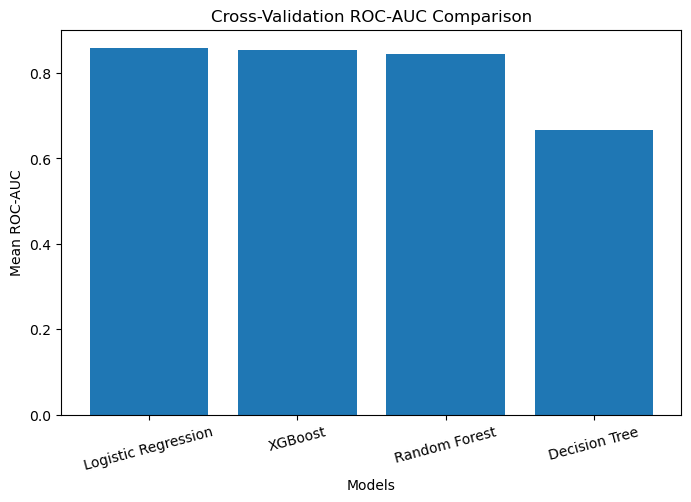

In [10]:
plt.figure(figsize=(8,5))

plt.bar(
    cv_results["Model"],
    cv_results["ROC AUC"]
)

plt.ylabel("Mean ROC-AUC")

plt.xlabel("Models")

plt.title("Cross-Validation ROC-AUC Comparison")

plt.xticks(rotation=15)

plt.show()

## Compare All Metrics

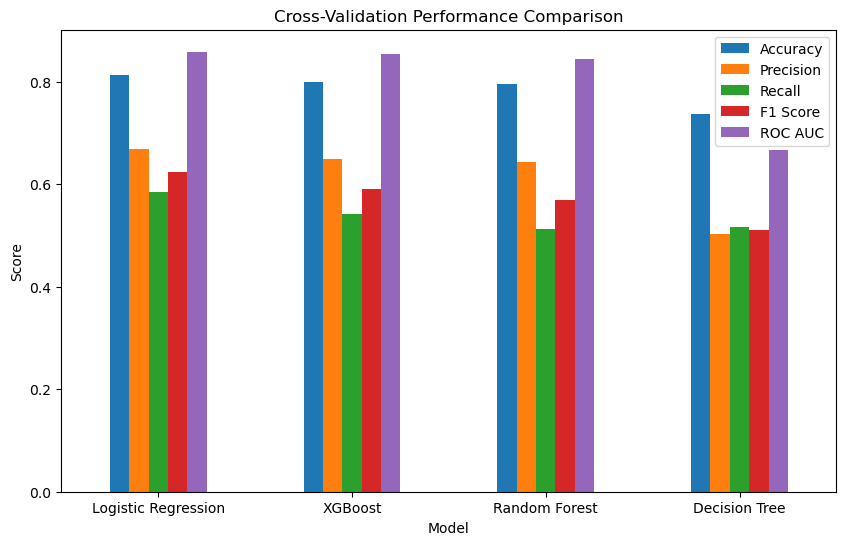

In [11]:
metrics = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1 Score",

    "ROC AUC"

]

cv_results.set_index("Model")[metrics].plot(

    kind="bar",

    figsize=(10,6)

)

plt.ylabel("Score")

plt.title("Cross-Validation Performance Comparison")

plt.xticks(rotation=0)

plt.show()

## Save Results

In [12]:
cv_results.to_csv(

    "cross_validation_results.csv",

    index=False

)

print("Results saved successfully.")

Results saved successfully.


# Conclusion

All baseline models were evaluated using 5-fold Stratified Cross-Validation.

Compared with evaluation from a single train-test split, cross-validation provides a more reliable estimate of model performance by averaging results across multiple folds.

The model with the highest mean ROC-AUC and a low standard deviation demonstrates both strong predictive performance and consistent behavior across different subsets of the training data.

These results will guide the selection of the model for handling class imbalance and subsequent hyperparameter tuning.

The selected model will now be evaluated under class imbalance handling techniques such as class weighting and SMOTE to determine whether minority-class detection can be improved.